# Wine Dataset Classification:

# Importing Libraries and Loading the Data:

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Hyperparameter Tuning:
from sklearn.model_selection import cross_val_score, GridSearchCV

In [95]:
import warnings

# Suppress all warning messages
warnings.filterwarnings('ignore')

In [96]:
df = pd.read_csv("data/WineQT.csv")

df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


# Understanding the Data:

In [97]:
print(f"Shape of Data: {df.shape}")

Shape of Data: (1143, 13)


In [98]:
print("Info of Data:")
df.info()

Info of Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [99]:
print("Description of Data")
df.describe()

Description of Data


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [100]:
print("Missing values in Data:")
df.isnull().sum()

Missing values in Data:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

# Handle missing values:

In [101]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)

In [102]:
print("Missing values in Data after Handling:")
df.isnull().sum()

Missing values in Data after Handling:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

# Visualize the Data:

## 1. Histogram:

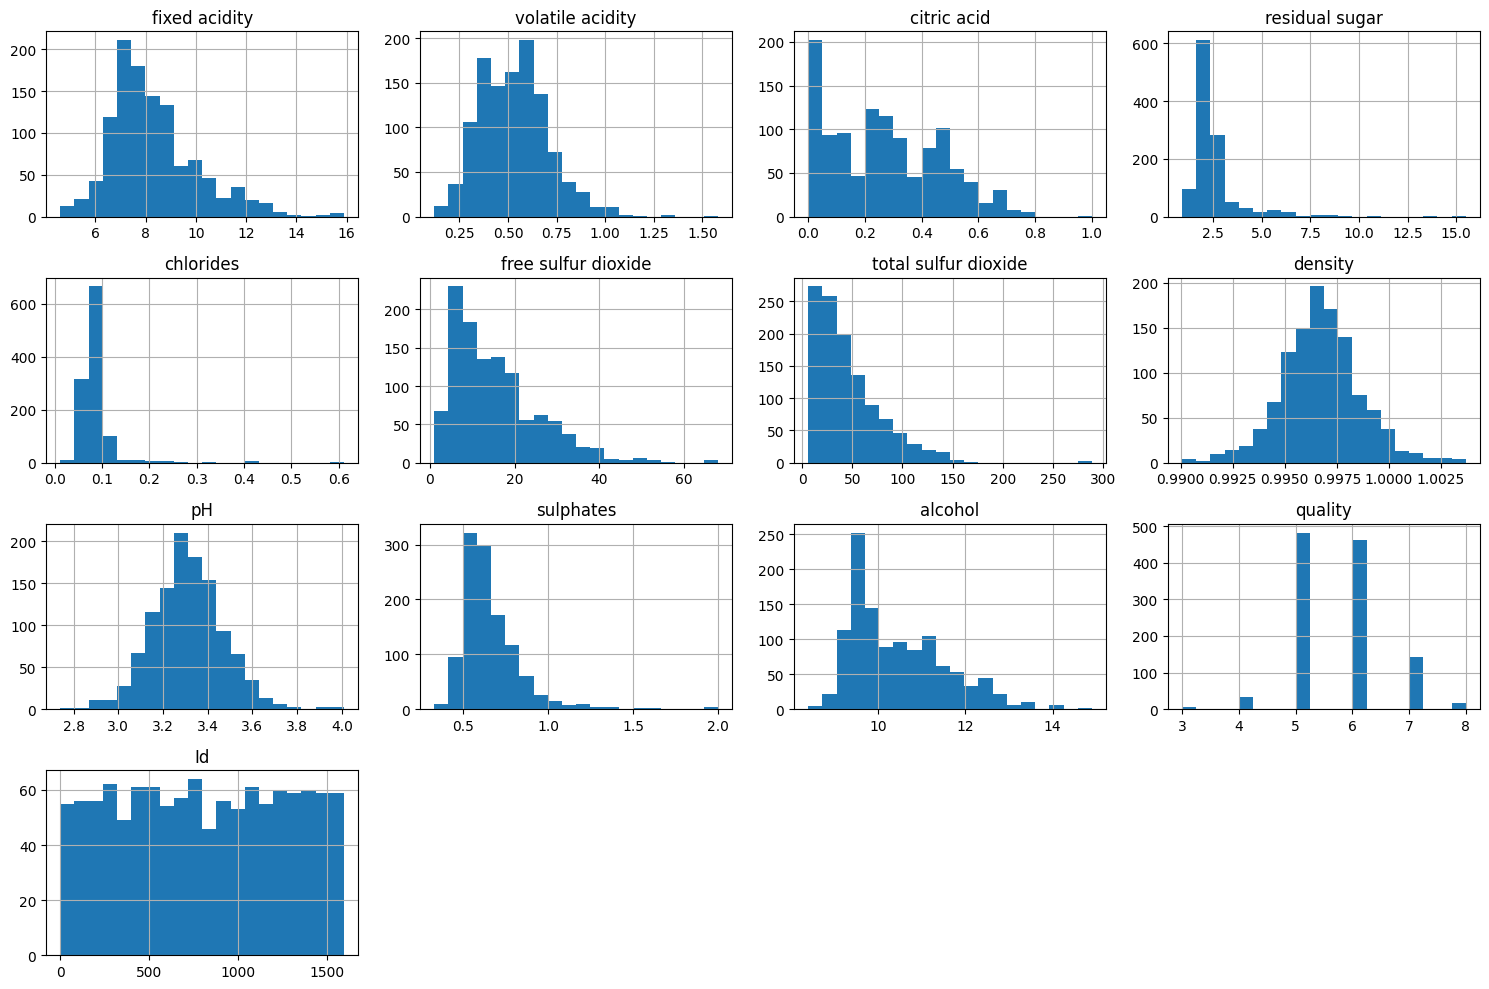

In [103]:
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

## 2. Correlation Heatmap:

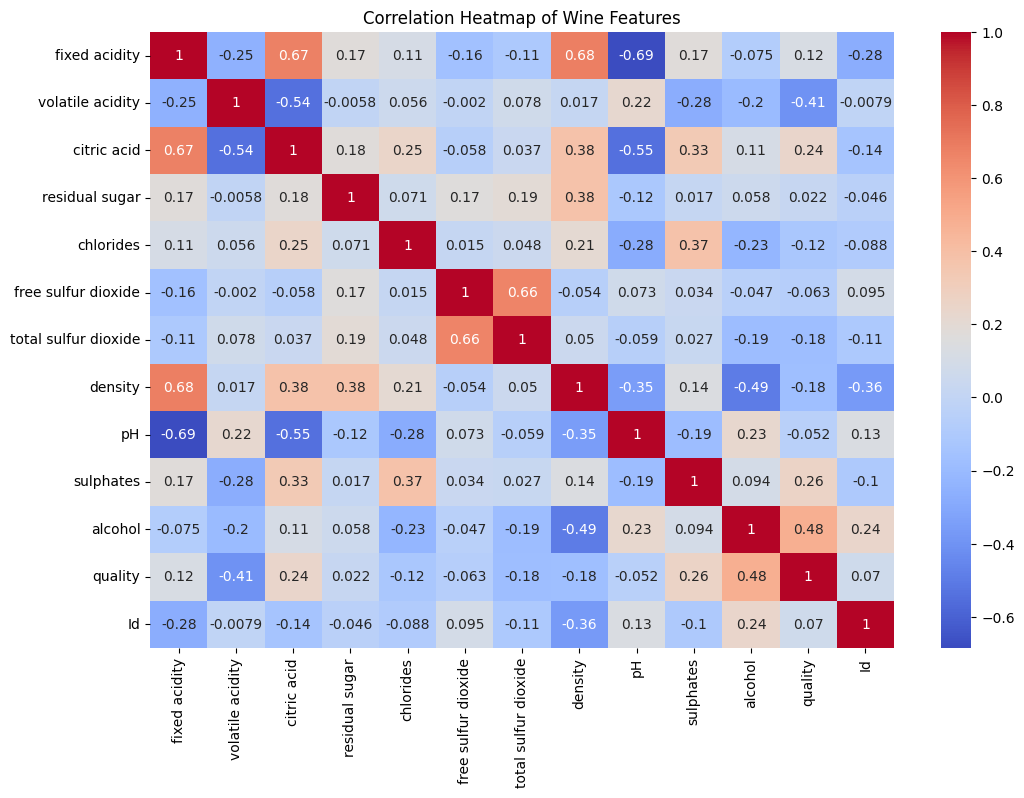

In [104]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Wine Features")
plt.show()

# Scaling:

## Min-Max Scalar:
- Range: 0 - 1

- Formula:

- - x′=$\frac{x - min(x)}{max(x) - min(x)}$

In [105]:
scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df.drop("quality", axis=1)),
    columns=df.columns[:-1]
)

df_scaled["quality"] = df["quality"]

df_scaled.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.247788,0.397260,0.00,0.068493,0.106845,0.149254,0.098940,0.567548,0.606299,0.137725,0.153846,5
1,0.283186,0.520548,0.00,0.116438,0.143573,0.358209,0.215548,0.494126,0.362205,0.209581,0.215385,5
2,0.283186,0.438356,0.04,0.095890,0.133556,0.208955,0.169611,0.508811,0.409449,0.191617,0.215385,5
3,0.584071,0.109589,0.56,0.068493,0.105175,0.238806,0.190813,0.582232,0.330709,0.149701,0.215385,6
4,0.247788,0.397260,0.00,0.068493,0.106845,0.149254,0.098940,0.567548,0.606299,0.137725,0.153846,5


## Checking the Description of Scaled Dataset:

In [106]:
df_scaled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,0.328417,0.281739,0.268364,0.111791,0.125096,0.218142,0.141041,0.489017,0.449618,0.196232,0.314171,5.657043
std,0.154654,0.123036,0.196686,0.092871,0.078910,0.152992,0.115838,0.141341,0.123358,0.102035,0.166492,0.805824
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.221239,0.186644,0.090000,0.068493,0.096828,0.089552,0.053004,0.403818,0.366142,0.131737,0.169231,5.000000
50%,0.292035,0.273973,0.250000,0.089041,0.111853,0.179104,0.109541,0.485316,0.448819,0.173653,0.276923,6.000000
75%,0.398230,0.356164,0.420000,0.116438,0.130217,0.298507,0.194346,0.570852,0.519685,0.239521,0.415385,6.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000


# Encode Target: quality

In [107]:
le = LabelEncoder()

X = df_scaled.drop("quality", axis=1)

y = le.fit_transform(df_scaled["quality"])

In [108]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1143, 11)
Target shape: (1143,)


# Train Test Split:

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [110]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (914, 11)
X_test : (229, 11)
y_train: (914,)
y_test : (229,)


# Model Training and Evaluation: 

In [111]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(random_state=42),
    
    "KNN": KNeighborsClassifier(),
    
    "SVM": SVC(probability=True),
    
    "XGBoost": XGBClassifier(eval_metric="mlogloss")
}

In [112]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)
    print(f"Model Trained: {name}")
    # Predict
    pred = model.predict(X_test)

    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test, pred, average="weighted"
        ),
        "Recall": recall_score(
            y_test, pred, average="weighted"
        ),
        "F1 Score": f1_score(
            y_test, pred, average="weighted"
        )
    })

Model Trained: Logistic Regression
Model Trained: Decision Tree
Model Trained: Random Forest
Model Trained: KNN
Model Trained: SVM
Model Trained: XGBoost


In [113]:
results_df = pd.DataFrame(results)
results_df.index += 1

results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.633188,0.608545,0.633188,0.609619
2,Decision Tree,0.532751,0.546789,0.532751,0.538993
3,Random Forest,0.689956,0.665100,0.689956,0.676725
4,KNN,0.576419,0.556316,0.576419,0.564041
5,SVM,0.624454,0.599904,0.624454,0.596052
6,XGBoost,0.681223,0.656194,0.681223,0.667305


## Sort By Accuracy:

In [114]:
results_df = results_df.sort_values(
    "Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.689956,0.665100,0.689956,0.676725
6,XGBoost,0.681223,0.656194,0.681223,0.667305
1,Logistic Regression,0.633188,0.608545,0.633188,0.609619
5,SVM,0.624454,0.599904,0.624454,0.596052
4,KNN,0.576419,0.556316,0.576419,0.564041
2,Decision Tree,0.532751,0.546789,0.532751,0.538993


# Compare the Models:

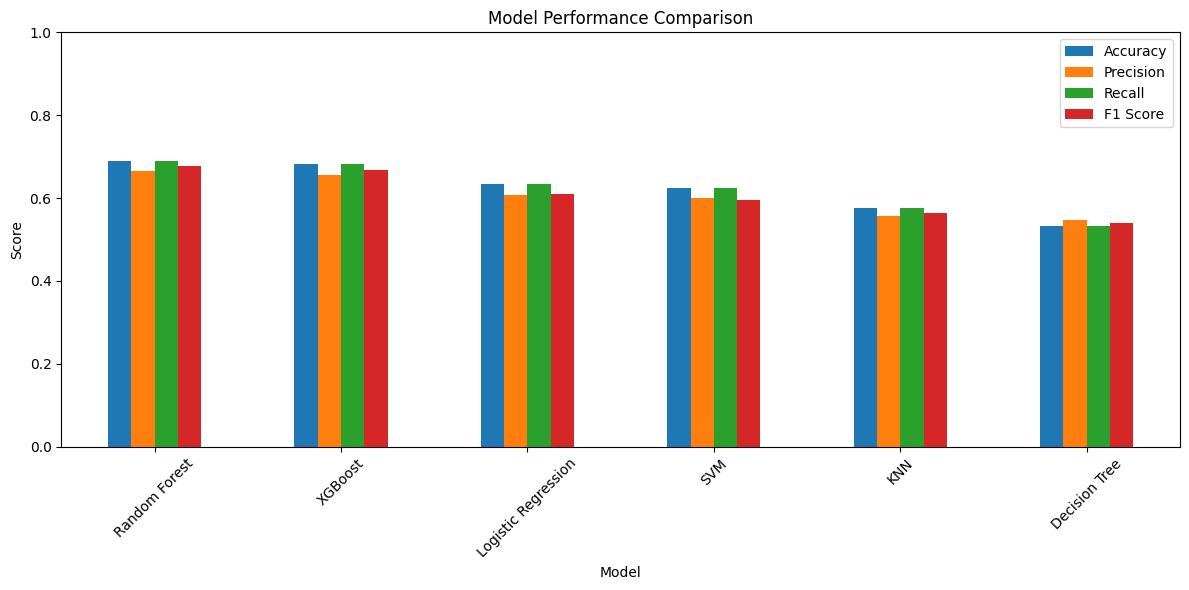

In [115]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Confusion Metrics:

Logistic Regression
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.67      0.75      0.71        96
           3       0.60      0.68      0.64        99
           4       0.60      0.23      0.33        26
           5       0.00      0.00      0.00         2

    accuracy                           0.63       229
   macro avg       0.37      0.33      0.34       229
weighted avg       0.61      0.63      0.61       229



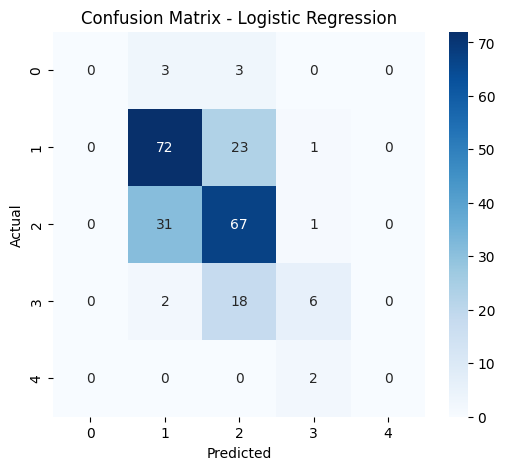

Decision Tree
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.14      0.17      0.15         6
           2       0.64      0.58      0.61        96
           3       0.53      0.53      0.53        99
           4       0.43      0.50      0.46        26
           5       0.00      0.00      0.00         2

    accuracy                           0.53       229
   macro avg       0.29      0.30      0.29       229
weighted avg       0.55      0.53      0.54       229



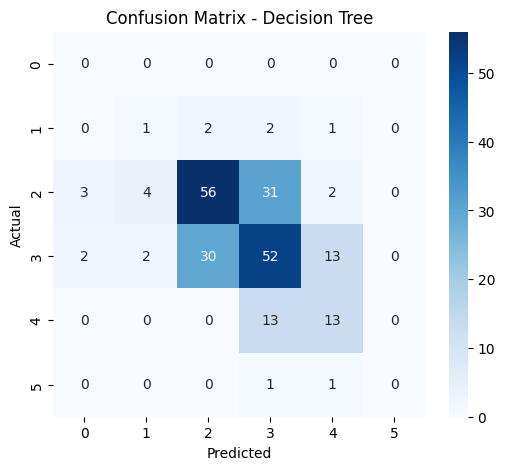

Random Forest
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.71      0.78      0.74        96
           3       0.66      0.66      0.66        99
           4       0.72      0.69      0.71        26
           5       0.00      0.00      0.00         2

    accuracy                           0.69       229
   macro avg       0.42      0.43      0.42       229
weighted avg       0.67      0.69      0.68       229



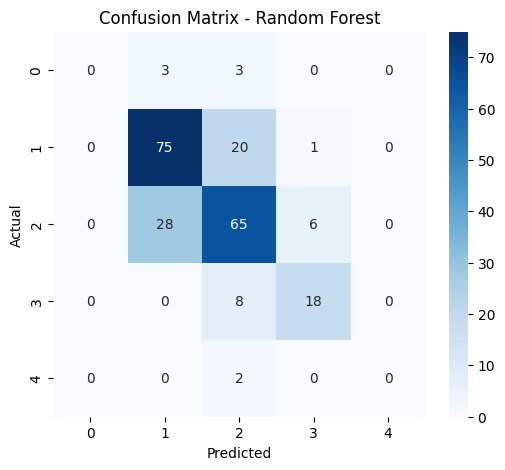

KNN
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.64      0.68      0.66        96
           3       0.56      0.61      0.58        99
           4       0.41      0.27      0.33        26
           5       0.00      0.00      0.00         2

    accuracy                           0.58       229
   macro avg       0.32      0.31      0.31       229
weighted avg       0.56      0.58      0.56       229



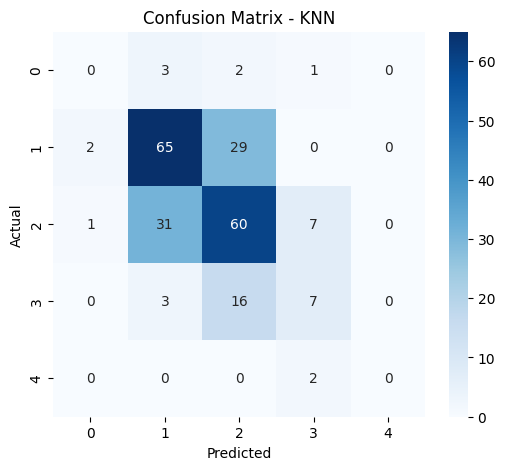

SVM
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.69      0.75      0.72        96
           3       0.57      0.68      0.62        99
           4       0.57      0.15      0.24        26
           5       0.00      0.00      0.00         2

    accuracy                           0.62       229
   macro avg       0.37      0.32      0.32       229
weighted avg       0.60      0.62      0.60       229



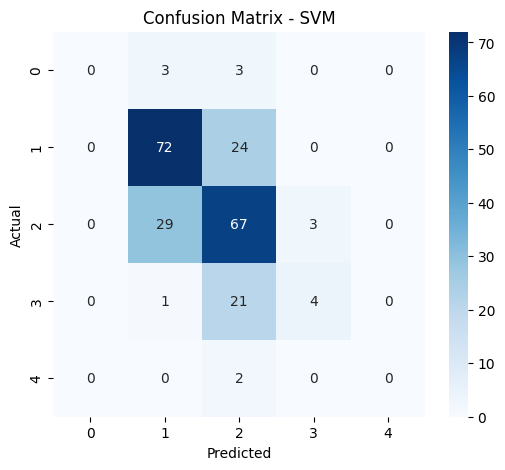

XGBoost
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.70      0.79      0.74        96
           3       0.66      0.64      0.65        99
           4       0.68      0.65      0.67        26
           5       0.00      0.00      0.00         2

    accuracy                           0.68       229
   macro avg       0.41      0.42      0.41       229
weighted avg       0.66      0.68      0.67       229



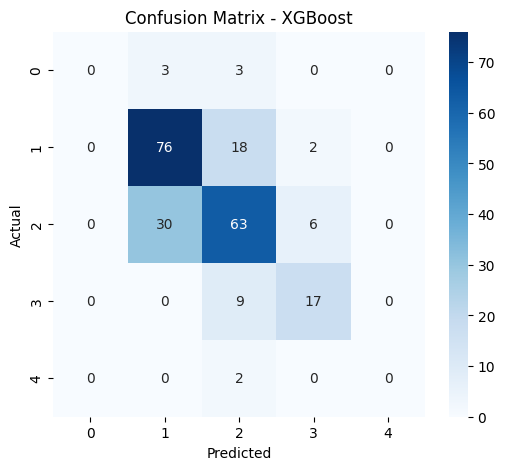

In [116]:
for name, model in models.items():

    pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 5 Fold Cross Validation:

In [117]:
for name, model in models.items():

    score = cross_val_score(
        model,
        X,
        y,
        cv=5
    )

    print(
        name,
        "CV Accuracy:",
        score.mean()
    )

Logistic Regression CV Accuracy: 0.5826936336474373
Decision Tree CV Accuracy: 0.5118440205316785
Random Forest CV Accuracy: 0.5739370259710412
KNN CV Accuracy: 0.5301654792001839
SVM CV Accuracy: 0.5853290431318472
XGBoost CV Accuracy: 0.5573354784340764


# Grid Search CV:

In [118]:
rf = RandomForestClassifier(
    random_state=42
)

In [119]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [120]:
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [121]:
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


# Get Tuned Random Forest:

In [122]:
best_rf = grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)

print(
    "Test Accuracy:",
    accuracy_score(y_test, best_rf_pred)
)

Test Accuracy: 0.6855895196506551


# Feature Importance:

In [123]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

In [124]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
10,alcohol,0.158928
9,sulphates,0.123296
1,volatile acidity,0.113269
6,total sulfur dioxide,0.097166
7,density,0.086710
4,chlorides,0.081772
0,fixed acidity,0.073994
2,citric acid,0.072099
8,pH,0.068687
5,free sulfur dioxide,0.062514


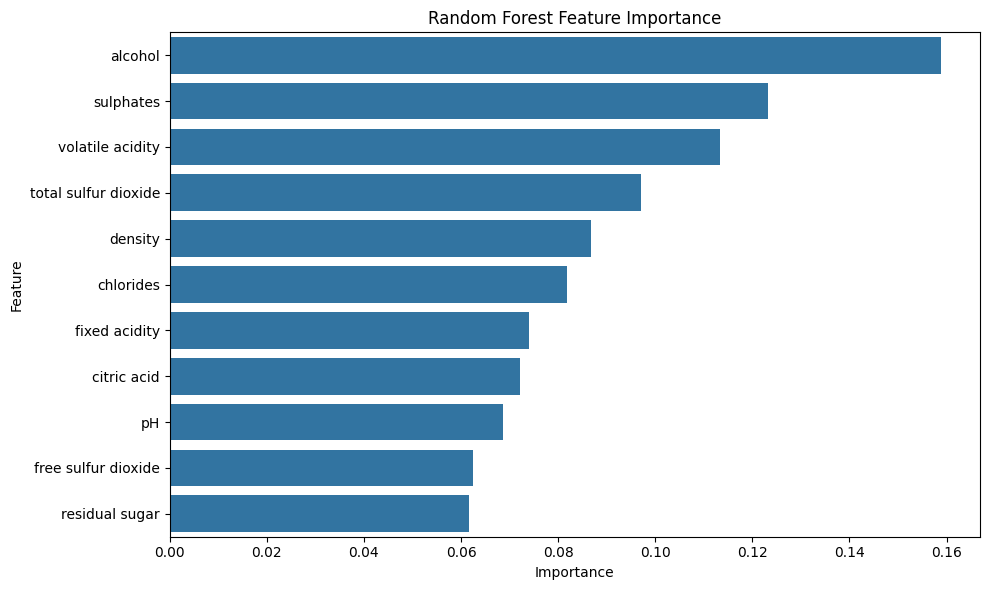

In [125]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# Final Model Leaderboard:

In [126]:
results_df.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.689956,0.665100,0.689956,0.676725
1,XGBoost,0.681223,0.656194,0.681223,0.667305
2,Logistic Regression,0.633188,0.608545,0.633188,0.609619
3,SVM,0.624454,0.599904,0.624454,0.596052
4,KNN,0.576419,0.556316,0.576419,0.564041
5,Decision Tree,0.532751,0.546789,0.532751,0.538993


# Conclusion:

The six classification models were trained and evaluated on the Wine Quality dataset using Accuracy, Precision, Recall and F1-Score. Random Forest achieved the highest test accuracy among the compared models in the reference results. GridSearchCV was then used to tune the Random Forest hyperparameters, and feature importance was analyzed to identify influential wine characteristics. The experiment demonstrated the use of classification, feature scaling, cross-validation and hyperparameter tuning for wine quality prediction.